#Tomato plant leaf disease classficaiton using ML

In [26]:
# Let us import the libraries

import cv2
import numpy as np
import os

from os import listdir
import matplotlib.pyplot as plt


In [27]:
# dataset_path=os.path.dirname(os.path.abspath('tomato.ipynb'))

# print(dataset_path)
# dataset_path=os.path.join(dataset_path,'dataset')
# print(dataset_path)

dataset_path="./dataset"


In [28]:
image="./dataset/bacterial_spot/img_bs_1.jpg"

testimage=cv2.imread(image)

print(testimage.shape)



(256, 256, 3)


In [29]:
X=testimage.reshape(1,-1)
X.shape

(1, 196608)

In [30]:
features=[]
labels=[]

i=0

In [31]:


for folder in listdir(dataset_path):
      
    folder_path=f"{dataset_path}/{folder}"
    for file in listdir(folder_path):
    
        image_path=f"{folder_path}/{file}"
        img=cv2.imread(image_path)
        img=cv2.resize(img,(64,64))
        features.append(img)
        # print(img)
        
        labels.append(i)    
    i=i+1   

In [32]:
X=np.array( features)
X=X.reshape( len(X),-1)
print(X.shape)

(1332, 12288)


In [33]:
y=np.array( labels)

In [34]:
# Let us device data into train and test

from sklearn.model_selection import train_test_split
Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=43)

In [35]:
# Let us use Random forest Classifier

from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(Xtrain,ytrain)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
# Let us evaluate the model
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

ypred=model.predict( Xtest )

score=accuracy_score(ytest,ypred)
print(f"Accuracy score of RF model is : {score*100}")

Accuracy score of RF model is : 86.14232209737828


In [37]:
cm=confusion_matrix(ytest,ypred)
cm

array([[80,  2,  4],
       [13, 71, 11],
       [ 2,  5, 79]])

In [38]:
cf=classification_report(ytest,ypred)
print(cf)

              precision    recall  f1-score   support

           0       0.84      0.93      0.88        86
           1       0.91      0.75      0.82        95
           2       0.84      0.92      0.88        86

    accuracy                           0.86       267
   macro avg       0.86      0.87      0.86       267
weighted avg       0.87      0.86      0.86       267



In [39]:
import joblib
joblib.dump(model,"rf_tomato_model.pkl")

['rf_tomato_model.pkl']

In [40]:
# Let us predict the image

test_image=cv2.imread("./dataset/healthy/img_h_1.jpg")

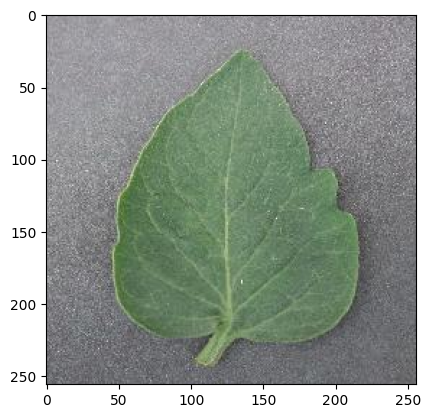

In [41]:
test_image=cv2.cvtColor(test_image,cv2.COLOR_BGR2RGB)
plt.imshow(test_image)

In [42]:
test_image=cv2.resize(test_image,(64,64))

test_image=test_image.reshape(1,-1)

rfModel=joblib.load("rf_tomato_model.pkl")

pred=rfModel.predict(test_image)
print(pred)

[2]
